In [1]:
# Imports 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from numpy import ndarray
from scipy.stats import gaussian_kde
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, ConstantKernel

sns.set_theme(style="white", context="notebook")

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

In [ ]:
data = pd.read_csv("data/Daily_Temp_Data.csv")
data['date'] = pd.to_datetime(data['date'], dayfirst=True, errors='coerce')
data = data[(data['date'].dt.year >= 2010) & (data['date'].dt.year <= 2022)].copy()

anchor = pd.Timestamp('2010-01-01')
blocks = ((data['date'] - anchor).dt.days // 7)
data['week_start'] = anchor + blocks * pd.Timedelta(days=7)
data['temp_weekly'] = data.groupby('week_start')['temp'].transform('mean')

weekly_unique = (
    data[['week_start', 'temp_weekly']]
    .drop_duplicates(subset='week_start')
    .dropna(subset=['temp_weekly'])
    .sort_values('week_start')
)

t0 = weekly_unique['week_start'].min()
weekly_unique['t_week'] = (weekly_unique['week_start'] - t0).dt.days / 7.0

X_full = weekly_unique[['t_week']].to_numpy()
y_full = weekly_unique['temp_weekly'].to_numpy()



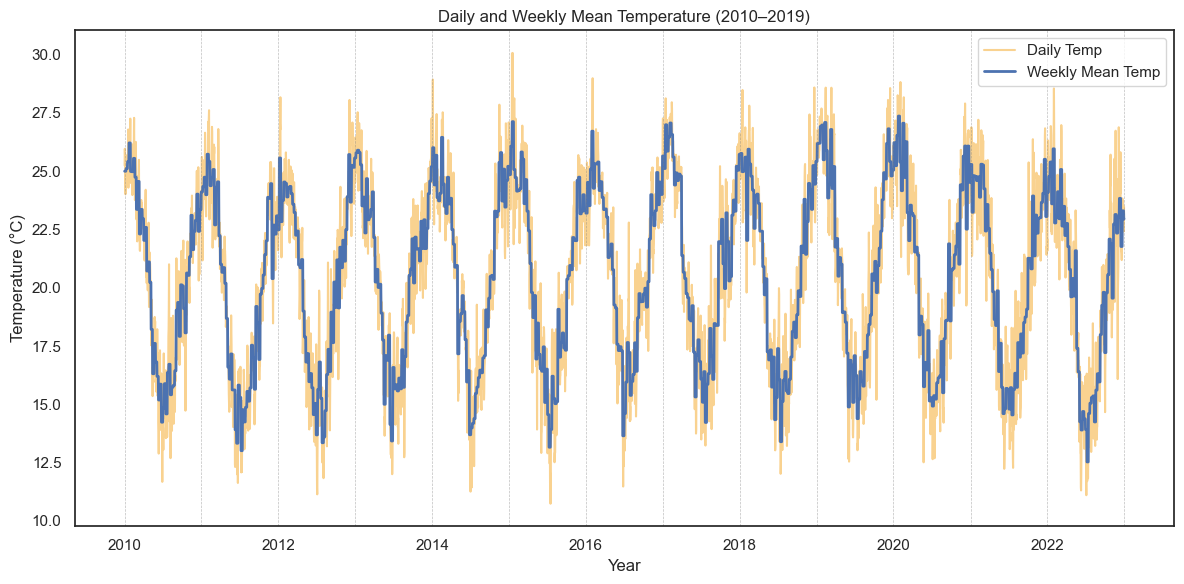

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['temp'], label='Daily Temp', alpha=0.5, color='#F5A623')
plt.plot(data['date'], data['temp_weekly'], label='Weekly Mean Temp', linewidth=2)

years = np.arange(2010, 2024)
for y in years:
    plt.axvline(pd.Timestamp(f'{y}-01-01'), color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.title('Daily and Weekly Mean Temperature (2010–2019)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
summary = data.describe()
print(summary)


                      date         temp                     week_start  \
count                 4748  4748.000000                           4748   
mean   2016-07-01 12:00:00    20.526029  2016-06-28 12:01:30.985678336   
min    2010-01-01 00:00:00    10.735000            2010-01-01 00:00:00   
25%    2013-04-01 18:00:00    17.263854            2013-03-29 00:00:00   
50%    2016-07-01 12:00:00    20.857142            2016-07-01 00:00:00   
75%    2019-10-01 06:00:00    23.815417            2019-09-27 00:00:00   
max    2022-12-31 00:00:00    30.074167            2022-12-30 00:00:00   
std                    NaN     3.893950                            NaN   

       temp_weekly  
count  4748.000000  
mean     20.526029  
min      12.527170  
25%      17.088062  
50%      20.879583  
75%      23.841103  
max      27.366424  
std       3.717223  


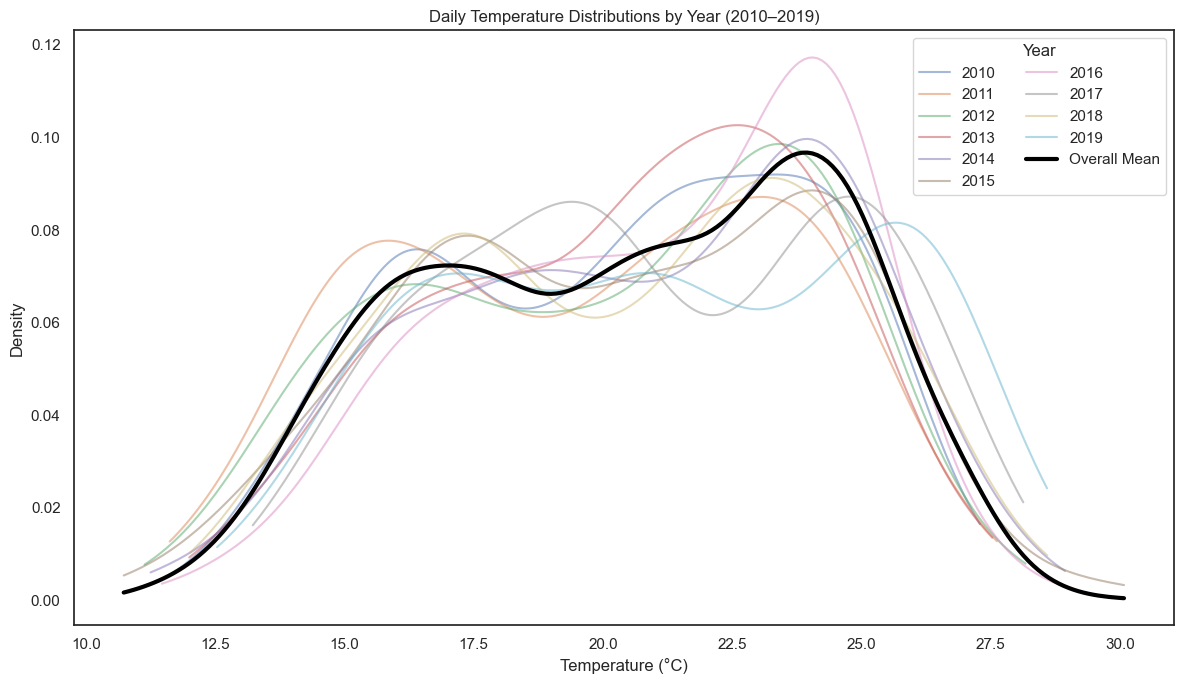

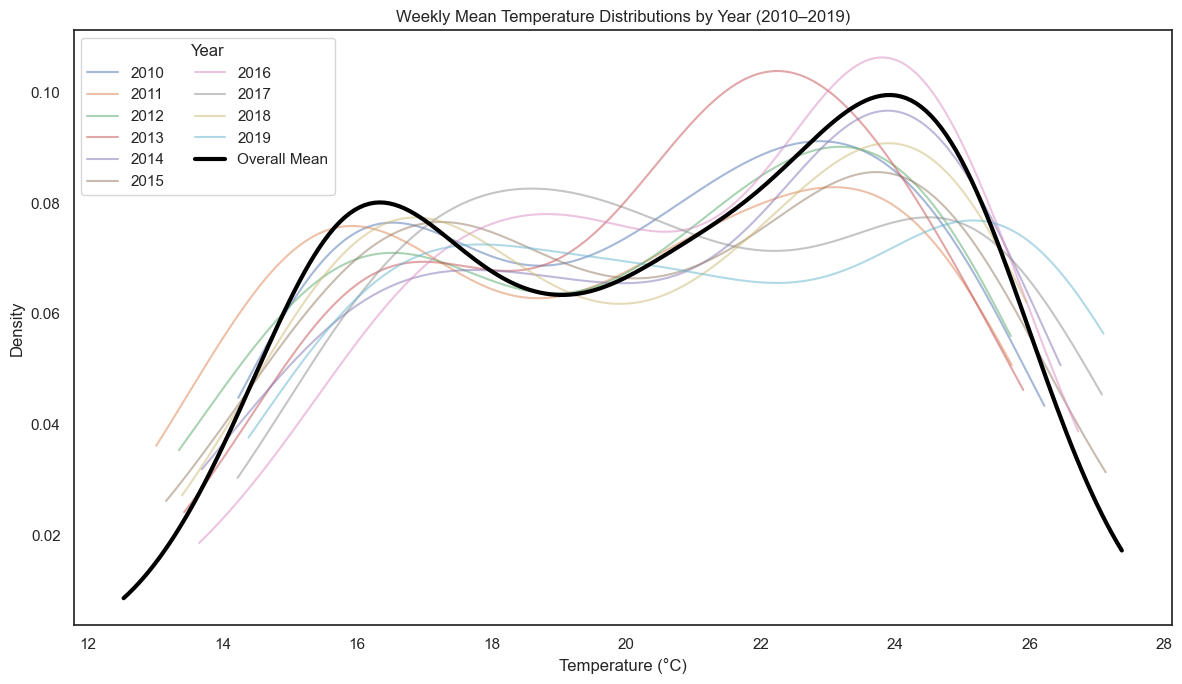

In [ ]:
data['year'] = pd.to_datetime(data['week_start']).dt.year

years = range(2010, 2020)

plt.figure(figsize=(12, 7))
for y in years:
    vals = data.loc[data['year'] == y, 'temp'].dropna().values
    if len(vals) > 1:
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        plt.plot(xs, kde(xs), label=str(y), alpha=0.5)

all_vals = data['temp'].dropna().values
kde_all = gaussian_kde(all_vals)
xs_all = np.linspace(all_vals.min(), all_vals.max(), 200)
plt.plot(xs_all, kde_all(xs_all), color='black', linewidth=3, label='Overall Mean')

plt.title('Daily Temperature Distributions by Year (2010–2019)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend(title='Year', ncol=2)
plt.tight_layout()
plt.show()

weekly_unique = (
    data[['week_start', 'temp_weekly']]
    .drop_duplicates(subset='week_start')
    .copy()
)
weekly_unique['year'] = weekly_unique['week_start'].dt.year

plt.figure(figsize=(12, 7))
for y in years:
    vals = weekly_unique.loc[weekly_unique['year'] == y, 'temp_weekly'].dropna().values
    if len(vals) > 1:
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        plt.plot(xs, kde(xs), label=str(y), alpha=0.5)

all_vals_w = weekly_unique['temp_weekly'].dropna().values
kde_all_w = gaussian_kde(all_vals_w)
xs_all_w = np.linspace(all_vals_w.min(), all_vals_w.max(), 200)
plt.plot(xs_all_w, kde_all_w(xs_all_w), color='black', linewidth=3, label='Overall Mean')

plt.title('Weekly Mean Temperature Distributions by Year (2010–2019)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend(title='Year', ncol=2)
plt.tight_layout()
plt.show()


In [6]:
train_mask = weekly_unique['week_start'].dt.year <= 2019
X_train = X_full[train_mask]
y_train = y_full[train_mask]

In [ ]:
kernel_lin = ConstantKernel(1.0) * RBF(length_scale=52)  
kernel_per = ConstantKernel(1.0) * ExpSineSquared(
    length_scale=6,
    periodicity=52,              
    periodicity_bounds=(50, 54)
) * RBF(4)

kernel_noi = WhiteKernel(noise_level=0.5, noise_level_bounds=(1e-5, 1e2))
kernel = kernel_lin + kernel_per + kernel_noi

In [8]:
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=RANDOM_SEED
)
gp.fit(X_train, y_train)
print("Optimized kernel:", gp.kernel_)

Optimized kernel: 0.0996**2 * RBF(length_scale=44.2) + 3.02**2 * ExpSineSquared(length_scale=3.81, periodicity=52.2) * RBF(length_scale=8.28e+03) + WhiteKernel(noise_level=0.078)


In [ ]:
H = 52 * (2022 - 2010 + 1)
x_future = np.linspace(X_full.min(), X_full.max(), 1000).reshape(-1, 1)
y_pred, y_std = gp.predict(x_future, return_std=True)

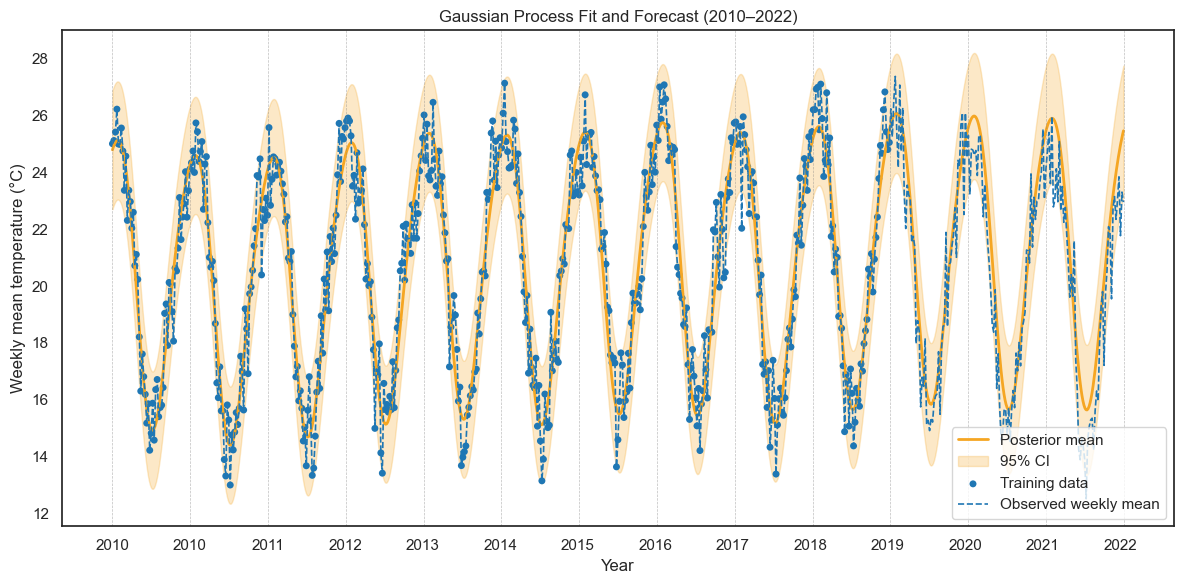

In [13]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=x_future.ravel(), y=y_pred, lw=2, color="#F5A623", label="Posterior mean")
plt.fill_between(
    x_future.ravel(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    color="#F5A623", alpha=0.25, label="95% CI"
)

sns.scatterplot(x=X_train.ravel(), y=y_train, s=25, color="#1f77b4", label="Training data", edgecolor="none")
sns.lineplot(x=X_full.ravel(), y=y_full, color="#1f77b4", linestyle="--", lw=1.2, label="Observed weekly mean")

weeks_per_year = 52
xticks = np.arange(0, x_future.max(), weeks_per_year)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year")
plt.ylabel("Weekly mean temperature (°C)")
plt.title("Gaussian Process Fit and Forecast (2010–2022)")

for year in np.arange(2010, 2024):
    x_week = (pd.Timestamp(f"{year}-01-01") - t0).days / 7
    plt.axvline(x=x_week, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()
